# CICIOST2023的測試檔案

In [3]:
import os
import kagglehub
import pandas as pd
from glob import glob

# 將 Kaggle 下載路徑指向 D 槽
os.environ["KAGGLEHUB_CACHE"] = "D:\\kaggle_cache"

# 下載資料集 (這會返回資料集所在的資料夾路徑)
path = kagglehub.dataset_download("madhavmalhotra/unb-cic-iot-dataset")
print(f"資料集已下載至: {path}")

資料集已下載至: D:\kaggle_cache\datasets\madhavmalhotra\unb-cic-iot-dataset\versions\1


In [4]:
import os
import pandas as pd
from glob import glob

target_path = r"D:\kaggle_cache\datasets\madhavmalhotra\unb-cic-iot-dataset\versions\1\wataiData\csv\CICIoT2023"
all_files = glob(os.path.join(target_path, "*.csv"))

print(f"找到的 CSV 檔案數量: {len(all_files)}")

if len(all_files) == 0:
    print("【錯誤】找不到檔案!")
else:
    df_list = []
    
    for i, filename in enumerate(all_files, 1):
        print(f"[{i}/{len(all_files)}] 正在讀取: {os.path.basename(filename)}")
        
        # 修正:移除多餘的 [ ]
        temp_df = pd.read_csv(filename)  
        
        # 顯示每個檔案的標籤資訊
        labels_in_file = temp_df['label'].unique()
        print(f"  └─ 此檔案包含 {len(labels_in_file)} 種標籤: {labels_in_file[:3]}...")
        
        df_list.append(temp_df)
    
    # 合併
    df = pd.concat(df_list, axis=0, ignore_index=True)
    
    print(f"\n--- 合併成功 ---")
    print(f"總資料列數: {len(df):,}")
    print(f"特徵數量: {df.shape[1]}")
    print(f"總標籤種類: {df['label'].nunique()}")
    print(f"\n所有標籤:")
    print(df['label'].value_counts())

找到的 CSV 檔案數量: 169
[1/169] 正在讀取: part-00000-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
  └─ 此檔案包含 34 種標籤: ['DDoS-RSTFINFlood' 'DoS-TCP_Flood' 'DDoS-ICMP_Flood']...
[2/169] 正在讀取: part-00001-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
  └─ 此檔案包含 34 種標籤: ['DDoS-SYN_Flood' 'DDoS-TCP_Flood' 'DDoS-SynonymousIP_Flood']...
[3/169] 正在讀取: part-00002-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
  └─ 此檔案包含 34 種標籤: ['Mirai-greeth_flood' 'DDoS-ICMP_Flood' 'DDoS-UDP_Flood']...
[4/169] 正在讀取: part-00003-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
  └─ 此檔案包含 34 種標籤: ['DDoS-PSHACK_Flood' 'DDoS-SynonymousIP_Flood' 'DDoS-TCP_Flood']...
[5/169] 正在讀取: part-00004-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
  └─ 此檔案包含 34 種標籤: ['Mirai-udpplain' 'DDoS-PSHACK_Flood' 'DDoS-ICMP_Flood']...
[6/169] 正在讀取: part-00005-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
  └─ 此檔案包含 34 種標籤: ['Mirai-greeth_flood' 'DDoS-PSHACK_Flood' 'Mirai-greip_flood']...
[7/169] 正在讀取: part-00006-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c0

In [5]:
import numpy as np

print("=== 採用溫和的資料清洗策略 ===")

# 1. 處理 inf 值:替換為 NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# 2. 計算每行的缺失比例
missing_ratio = df.isnull().sum(axis=1) / df.shape[1]

# 3. 只刪除缺失值超過 50% 的行 (而非刪除任何有缺失的行)
threshold = 0.5
before = len(df)
df = df[missing_ratio <= threshold]
after = len(df)

print(f"刪除缺失值 > {threshold*100}% 的行")
print(f"刪除前: {before:,} 筆")
print(f"刪除後: {after:,} 筆")
print(f"保留率: {after/before*100:.2f}%")

# 4. 對剩餘的缺失值填充 (用中位數或眾數)
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

print("\n清洗後的標籤分佈:")
print(df['label'].value_counts())

=== 採用溫和的資料清洗策略 ===
刪除缺失值 > 50.0% 的行
刪除前: 46,686,579 筆
刪除後: 46,686,579 筆
保留率: 100.00%

清洗後的標籤分佈:
label
DDoS-ICMP_Flood            7200504
DDoS-UDP_Flood             5412287
DDoS-TCP_Flood             4497667
DDoS-PSHACK_Flood          4094755
DDoS-SYN_Flood             4059190
DDoS-RSTFINFlood           4045285
DDoS-SynonymousIP_Flood    3598138
DoS-UDP_Flood              3318595
DoS-TCP_Flood              2671445
DoS-SYN_Flood              2028834
BenignTraffic              1098195
Mirai-greeth_flood          991866
Mirai-udpplain              890576
Mirai-greip_flood           751682
DDoS-ICMP_Fragmentation     452489
MITM-ArpSpoofing            307593
DDoS-UDP_Fragmentation      286925
DDoS-ACK_Fragmentation      285104
DNS_Spoofing                178911
Recon-HostDiscovery         134378
Recon-OSScan                 98259
Recon-PortScan               82284
DoS-HTTP_Flood               71864
VulnerabilityScan            37382
DDoS-HTTP_Flood              28790
DDoS-SlowLoris        

In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder

# 1. 類別映射表 (將原始數據集的 33 種標籤歸類為 7 大類，在加1類正常流量)
# 這裡根據 CIC-IoT-2023 的特性進行映射
mapping = {
    # /***  DDoS 類別   ***/ 
    'DDoS-ACK_Fragmentation': 'DDoS',
    'DDoS-UDP_Flood': 'DDoS',
    'DDoS-SlowLoris': 'DDoS',
    'DDoS-ICMP_Flood': 'DDoS',
    'DDoS-RSTFIN_Flood': 'DDoS',
    'DDoS-PSHACK_Flood': 'DDoS',
    'DDoS-HTTP_Flood': 'DDoS',
    'DDoS-UDP_Fragmentation': 'DDoS',
    'DDoS-TCP_Flood': 'DDoS',
    'DDoS-SYN_Flood': 'DDoS',
    'DDoS-SynonymousIP_Flood': 'DDoS',
    'DDoS-ICMP_Fragmentation': 'DDoS',
    
    #----------------------------------
    
    # /***  Brute Force 類別   ***/
    'DictionaryBruteForce': 'Brute Force',
    
    #----------------------------------
    
    # /***  Spoofing 類別   ***/
    'MITM-ArpSpoofing': 'Spoofing',
    'DNS_Spoofing': 'Spoofing',
    
    #----------------------------------
    
    # /***  Dos 類別   ***/
    'DoS-TCP_Flood': 'DoS',
    'DoS-HTTP_Flood': 'DoS',
    'DoS-SYN_Flood': 'DoS',
    'DoS-UDP_Flood': 'DoS',
    
    #----------------------------------
    
    # /***  Recon 類別   ***/
    'Recon-HostDiscovery':'Recon',
    'Recon-OSScan': 'Recon',
    'Recon-PortScan': 'Recon',
    'Recon-PingSweep': 'Recon',
    'VulnerabilityScan': 'Recon',
    
    #----------------------------------
    
    # /***  Web-based 類別   ***/
    'SqlInjection': 'Web-based',
    'XSS': 'Web-based',
    'CommandInjection': 'Web-based',
    'Backdoor_Detection': 'Web-based', 
    'Uploading_Attack': 'Web-based',
    'BrowserHijacking': 'Web-based',
    
    #----------------------------------
    
    # /***  Mirai 類別   ***/
    'Mirai-greeth_flood': 'Mirai',
    'Mirai-udpplain': 'Mirai',
    'Mirai-greip_flood': 'Mirai',
    
    #----------------------------------
        
    # /***  Benign 類別   ***/
    'BenignTraffic': 'Benign',
    
    #----------------------------------
}

# 假設 df 已經是你之前合併好的 DataFrame
# 執行映射
df['label_category'] = df['label'].map(mapping)
# 如果有沒對應到的，統一歸為 Benign 或刪除
df.dropna(subset=['label_category'], inplace=True)

# 2. 資料清洗
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

# 3. 特徵與標籤準備
X = df.drop(['label', 'label_category'], axis=1)
y = df['label_category']

# 將文字標籤轉為數字
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# 4. 資料切割 (7:2:1)
# 先切出 70% 訓練集，剩餘 30% 給 (測試+驗證)
X_train, X_temp, y_train, y_temp = train_test_split(X, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded)

# 再從 30% 中切出 2/3 給測試集 (即總體的 20%)，1/3 給驗證集 (即總體的 10%)
X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.3333, random_state=42, stratify=y_temp)

print(f"訓練集大小: {X_train.shape[0]}, 測試集大小: {X_test.shape[0]}, 驗證集大小: {X_val.shape[0]}")

# 5. 建立隨機森林模型
rf_model = RandomForestClassifier(
    n_estimators=100,    # 樹的數量
    max_depth=20,        # 限制深度防止過擬合
    n_jobs=6,           # 使用所有 CPU 核心加速
    random_state=42
)

# 6. 訓練模型
print("開始訓練隨機森林...")
rf_model.fit(X_train, y_train)

# 7. 驗證與測試
y_val_pred = rf_model.predict(X_val)
print("\n--- 驗證集表現 ---")
print(f"準確率: {accuracy_score(y_val, y_val_pred):.4f}")

y_test_pred = rf_model.predict(X_test)
print("\n--- 測試集報告 ---")
print(classification_report(y_test, y_test_pred, target_names=le.classes_))

訓練集大小: 29846653, 測試集大小: 8528041, 驗證集大小: 4263382
開始訓練隨機森林...

--- 驗證集表現 ---
準確率: 0.9958

--- 測試集報告 ---
              precision    recall  f1-score   support

      Benign       0.91      0.98      0.94    219650
 Brute Force       1.00      0.47      0.64      2613
        DDoS       1.00      1.00      1.00   5988154
         DoS       1.00      1.00      1.00   1618228
       Mirai       1.00      1.00      1.00    526851
       Recon       0.91      0.82      0.86     70917
    Spoofing       0.92      0.85      0.89     97306
   Web-based       1.00      0.32      0.49      4322

    accuracy                           1.00   8528041
   macro avg       0.97      0.81      0.85   8528041
weighted avg       1.00      1.00      1.00   8528041



In [7]:
# 查看原始資料集的所有標籤
print("=== 原始資料集的所有標籤 ===")
original_labels = df['label'].value_counts()
print(original_labels)
print(f"\n總共 {len(original_labels)} 種原始標籤")

# 特別檢查 DDoS 相關標籤
print("\n=== 尋找 DDoS 相關標籤 ===")
all_labels = df['label'].unique()
ddos_related = [label for label in all_labels if 'ddos' in label.lower()]
print(f"找到的 DDoS 相關標籤: {ddos_related}")

# 檢查你的 mapping 中定義的 DDoS 標籤是否真的存在於資料集
print("\n=== 檢查 mapping 中的 DDoS 標籤是否存在 ===")
ddos_in_mapping = [k for k, v in mapping.items() if v == 'DDoS']
print(f"Mapping 中定義的 DDoS 標籤共 {len(ddos_in_mapping)} 個:")
for label in ddos_in_mapping:
    exists = label in all_labels
    print(f"  {label}: {'✓ 存在' if exists else '✗ 不存在於資料集'}")

=== 原始資料集的所有標籤 ===
label
DDoS-ICMP_Flood            7200504
DDoS-UDP_Flood             5412287
DDoS-TCP_Flood             4497667
DDoS-PSHACK_Flood          4094755
DDoS-SYN_Flood             4059190
DDoS-SynonymousIP_Flood    3598138
DoS-UDP_Flood              3318595
DoS-TCP_Flood              2671445
DoS-SYN_Flood              2028834
BenignTraffic              1098195
Mirai-greeth_flood          991866
Mirai-udpplain              890576
Mirai-greip_flood           751682
DDoS-ICMP_Fragmentation     452489
MITM-ArpSpoofing            307593
DDoS-UDP_Fragmentation      286925
DDoS-ACK_Fragmentation      285104
DNS_Spoofing                178911
Recon-HostDiscovery         134378
Recon-OSScan                 98259
Recon-PortScan               82284
DoS-HTTP_Flood               71864
VulnerabilityScan            37382
DDoS-HTTP_Flood              28790
DDoS-SlowLoris               23426
DictionaryBruteForce         13064
BrowserHijacking              5859
CommandInjection              

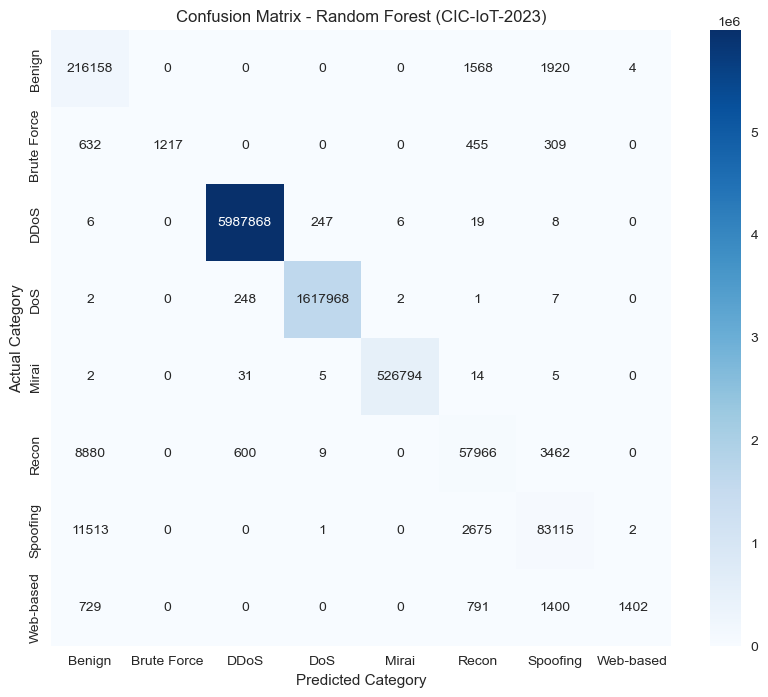

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_recall_fscore_support

# 設定字體與風格
plt.style.use('seaborn-v0_8') 

# --- A. 繪製混淆矩陣 (Confusion Matrix) ---
def plot_conf_matrix(y_true, y_pred, classes):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=classes, yticklabels=classes)
    plt.title('Confusion Matrix - Random Forest (CIC-IoT-2023)')
    plt.ylabel('Actual Category')
    plt.xlabel('Predicted Category')
    plt.show()



# --- 執行繪圖 ---
# 這裡使用 LabelEncoder 的 classes_ 來確保標籤文字正確
class_names = le.classes_

plot_conf_matrix(y_test, y_test_pred, class_names)


In [9]:
# --- B. 建立性能指標表 (Accuracy, Precision, Recall, F1-Score) ---
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, accuracy_score, precision_recall_fscore_support

plt.style.use('seaborn-v0_8') 

def get_metrics_table(y_true, y_pred, classes):
    # 計算各類別的指標
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average=None)
    
    # 建立表格
    metrics_df = pd.DataFrame({
        'Category': classes,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    })
    
    # 計算整體平均 (Macro Average)
    macro_avg = precision_recall_fscore_support(y_true, y_pred, average='macro')
    # 計算整體準確率 (Accuracy)
    acc = accuracy_score(y_true, y_pred)
    
    print(f"Overall Accuracy: {acc:.4f}")
    return metrics_df

performance_table = get_metrics_table(y_test, y_test_pred, class_names)
print(performance_table.to_string(index=False))



Overall Accuracy: 0.9958
   Category  Precision   Recall  F1-Score
     Benign   0.908525 0.984102  0.944804
Brute Force   1.000000 0.465748  0.635509
       DDoS   0.999853 0.999952  0.999903
        DoS   0.999838 0.999839  0.999839
      Mirai   0.999985 0.999892  0.999938
      Recon   0.913009 0.817378  0.862551
   Spoofing   0.921187 0.854161  0.886409
  Web-based   0.995739 0.324387  0.489354


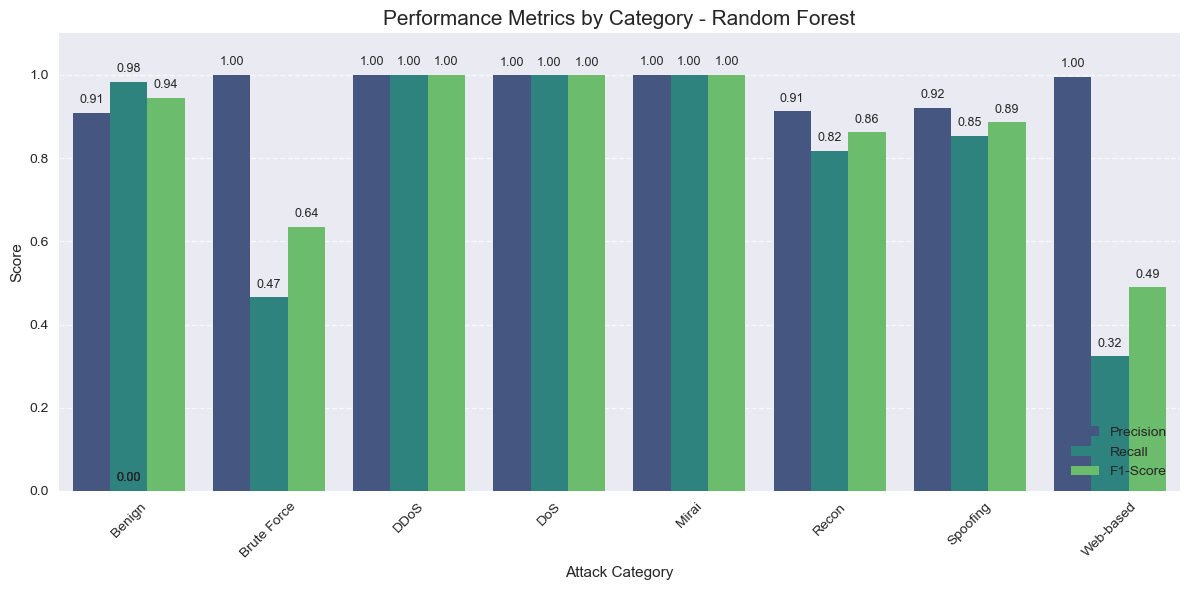

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 整理資料格式以利繪圖
# 我們將 performance_table 轉換為「長格式 (Long format)」
df_plot = performance_table.melt(id_vars='Category', var_name='Metric', value_name='Score')

# 2. 開始繪圖
plt.figure(figsize=(12, 6))
sns.barplot(data=df_plot, x='Category', y='Score', hue='Metric', palette='viridis')

# 3. 美化圖表
plt.title('Performance Metrics by Category - Random Forest', fontsize=15)
plt.ylim(0, 1.1) # 分數範圍 0 到 1
plt.ylabel('Score')
plt.xlabel('Attack Category')
plt.legend(loc='lower right')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 在長條圖上標註數值 (可選)
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.2f}', 
                       (p.get_x() + p.get_width() / 2., p.get_height()), 
                       ha = 'center', va = 'center', 
                       xytext = (0, 9), 
                       textcoords = 'offset points',
                       fontsize=9)

plt.tight_layout()
plt.show()

In [11]:
import joblib
import os
import pandas as pd
from datetime import datetime
from sklearn.metrics import accuracy_score, classification_report

# ============================================
# 保存完整的訓練套件 (含驗證集數據)
# ============================================

def save_complete_model(model, le, feature_names, X_train, y_train, 
                        X_test, y_test, y_test_pred, X_val, y_val, save_dir='models'):
    """
    保存完整的模型及相關資訊，並包含驗證集數據以供參考
    """
    
    # 建立保存目錄
    os.makedirs(save_dir, exist_ok=True)
    
    # 生成時間戳記
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    
    # 計算評估指標
    test_accuracy = accuracy_score(y_test, y_test_pred)
    
    # 建立完整的模型套件
    model_package = {
        'model': model,
        'label_encoder': le,
        'feature_names': feature_names,
        'validation_data': {
            'X': X_val,
            'y': y_val
        },
        'config': {
            'n_estimators': model.n_estimators,
            'max_depth': model.max_depth,
            'random_state': model.random_state,
        },
        'training_info': {
            'train_samples': X_train.shape[0],
            'test_samples': X_test.shape[0],
            'val_samples': X_val.shape[0],
            'n_features': X_train.shape[1],
            'n_classes': len(le.classes_),
        },
        'performance': {
            'test_accuracy': test_accuracy,
            'classification_report': classification_report(
                y_test, y_test_pred, 
                target_names=le.classes_,
                output_dict=True
            )
        },
        'feature_importance': dict(zip(
            feature_names, 
            model.feature_importances_
        )),
        'timestamp': timestamp
    }
    
    # 保存完整套件
    package_path = os.path.join(save_dir, f'complete_model_{timestamp}.joblib')
    joblib.dump(model_package, package_path)
    print(f"✓ 完整模型套件已保存至: {package_path}")
    
    # 保存純文字報告
    report_path = os.path.join(save_dir, f'model_report_{timestamp}.txt')
    with open(report_path, 'w', encoding='utf-8') as f:
        f.write("=" * 60 + "\n")
        f.write("隨機森林模型訓練報告 (含驗證集封裝)\n")
        f.write("=" * 60 + "\n\n")
        f.write(f"訓練時間: {timestamp}\n")
        f.write(f"測試集準確率: {test_accuracy:.4f}\n\n")
        f.write(f"訓練集樣本數: {X_train.shape[0]:,}\n")
        f.write(f"測試集樣本數: {X_test.shape[0]:,}\n")
        f.write(f"驗證集樣本數: {X_val.shape[0]:,}\n")
        f.write(f"特徵數量: {X_train.shape[1]}\n")
        f.write(f"類別數量: {len(le.classes_)}\n\n")
        f.write("類別列表:\n")
        for i, cls in enumerate(le.classes_, 1):
            f.write(f"  {i}. {cls}\n")
        f.write("\n" + "=" * 60 + "\n")
        f.write("測試集分類報告:\n")
        f.write("=" * 60 + "\n")
        f.write(classification_report(y_test, y_test_pred, target_names=le.classes_))
    
    print(f"✓ 模型報告已保存至: {report_path}")
    return package_path, report_path


# ============================================
# 載入完整模型套件
# ============================================

def load_complete_model(package_path):
    package = joblib.load(package_path)
    print("=" * 60)
    print("✓ 完整模型套件載入成功")
    print(f"訓練時間: {package['timestamp']}")
    print(f"驗證集樣本數: {package['training_info'].get('val_samples', 'N/A')}")
    print(f"類別列表: {package['label_encoder'].classes_}")
    print("=" * 60)
    return package


# ============================================
# 實際執行範例
# ============================================

# 1. 保存模型 (傳入 X_val, y_val)
feature_names = X_train.columns.tolist()
package_path, report_path = save_complete_model(
    rf_model, le, feature_names, 
    X_train, y_train, X_test, y_test, y_test_pred, 
    X_val, y_val,  # 新增的參數
    save_dir='models'
)

# 2. 載入模型
loaded_package = load_complete_model(package_path)

# 3. 提取驗證集數據 
X_val_from_file = loaded_package['validation_data']['X']
y_val_from_file = loaded_package['validation_data']['y']

print(f"\n從模型檔中提取的驗證集形狀: {X_val_from_file.shape}")
print("驗證集前 5 筆特徵數據:")
print(X_val_from_file.head())

# 4. 使用載入的模型驗證提取出的數據
val_preds = loaded_package['model'].predict(X_val_from_file)
val_acc = accuracy_score(y_val_from_file, val_preds)
print(f"\n驗證集重新測試準確率: {val_acc:.4f}")

✓ 完整模型套件已保存至: models\complete_model_20260508_210127.joblib
✓ 模型報告已保存至: models\model_report_20260508_210127.txt
✓ 完整模型套件載入成功
訓練時間: 20260508_210127
驗證集樣本數: 4263382
類別列表: ['Benign' 'Brute Force' 'DDoS' 'DoS' 'Mirai' 'Recon' 'Spoofing'
 'Web-based']

從模型檔中提取的驗證集形狀: (4263382, 46)
驗證集前 5 筆特徵數據:
          flow_duration  Header_Length  Protocol Type  Duration         Rate  \
28289952       0.000000          54.00           6.00     64.00    41.170072   
1297638        0.007269         181.96          16.89     65.74     6.989398   
3273840        0.093570       45447.50          16.68     67.82  9711.824170   
38281484       0.085577       26825.00          17.00     64.00  7203.988954   
37236904       1.419834          78.84           6.00     64.00     0.659154   

                Srate  Drate  fin_flag_number  syn_flag_number  \
28289952    41.170072    0.0              0.0              0.0   
1297638      6.989398    0.0              0.0              0.0   
3273840   9711.824170    0.0   